In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("Sample - Superstore.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape


(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df['Year'] = df['Order Date'].dt.year

In [ ]:
df['Month'] = df['Order Date'].dt.month

In [ ]:
df['Day'] = df['Order Date'].dt.day

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,12
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,11


In [ ]:
print(df['Sales'].sum())

2297200.8603000003


In [ ]:
print(df['Profit'].sum())

286397.0217


In [ ]:
df.groupby(
    'Category'
)['Sales'].sum()

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


In [ ]:
df.groupby(
    'Region'
)['Sales'].sum()

,Sales
Region,
Central,501239.8908
East,678781.2400
South,391721.9050
West,725457.8245


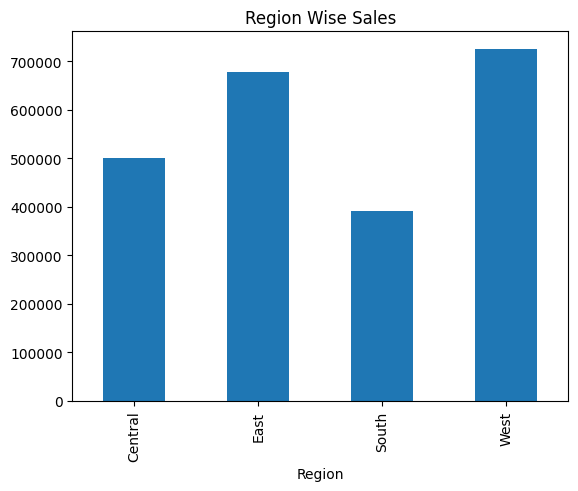

In [ ]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum()

region_sales.plot(kind='bar')

plt.title('Region Wise Sales')

plt.show()

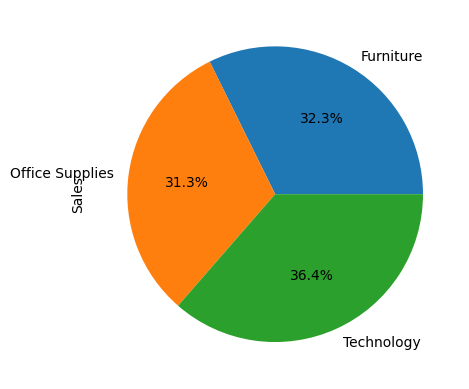

In [ ]:
category_sales = df.groupby(
    'Category'
)['Sales'].sum()

category_sales.plot(kind='pie',
                    autopct='%1.1f%%')

plt.show()

In [ ]:
X = df[
    [
     'Quantity',
     'Discount',
     'Profit'
    ]
]

y = df['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(
    X_test
)

In [ ]:
from sklearn.metrics import r2_score

print(
    r2_score(
        y_test,
        predictions
    )
)

0.5545712660322168


In [ ]:
X_test = X_test.copy()

X_test['Actual_Sales'] = y_test

X_test['Predicted_Sales'] = predictions

X_test.head()

,Quantity,Discount,Profit,Actual_Sales,Predicted_Sales
3125,4,0.2,21.1428,563.808,410.923780
1441,2,0.2,11.4600,36.672,41.063920
4510,2,0.0,17.1580,37.300,89.297100
39,3,0.3,-15.1470,212.058,442.328846
4509,3,0.2,-6.4233,171.288,115.816000


In [ ]:
customer_data = df[
    [
     'Sales',
     'Profit',
     'Quantity'
    ]
]

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Customer_Segment'] = kmeans.fit_predict(
    customer_data
)

In [ ]:
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
0,9503
1,475
3,13
2,3


In [ ]:
df.to_csv(
    'superstore_dashboard_data.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download(
    'superstore_dashboard_data.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
df = pd.read_csv("superstore_dashboard_data.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
X = df[['Quantity', 'Discount', 'Profit']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
results = X_test.copy()

results['Actual_Sales'] = y_test.values
results['Predicted_Sales'] = predictions

results.head()

,Quantity,Discount,Profit,Actual_Sales,Predicted_Sales
3125,4,0.2,21.1428,563.808,410.923780
1441,2,0.2,11.4600,36.672,41.063920
4510,2,0.0,17.1580,37.300,89.297100
39,3,0.3,-15.1470,212.058,442.328846
4509,3,0.2,-6.4233,171.288,115.816000


In [ ]:
from sklearn.cluster import KMeans

customer_data = df[['Sales', 'Profit', 'Quantity']]

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df['Customer_Segment'] = kmeans.fit_predict(customer_data)

In [ ]:
df.loc[X_test.index, 'Actual_Sales'] = y_test
df.loc[X_test.index, 'Predicted_Sales'] = predictions

In [ ]:
df['Actual_Sales'] = df['Actual_Sales'].fillna(df['Sales'])
df['Predicted_Sales'] = df['Predicted_Sales'].fillna(df['Sales'])

In [ ]:
df.to_csv(
    "superstore_dashboard_data.csv",
    index=False
)

In [ ]:
from google.colab import files

files.download("superstore_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>